In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

In [51]:
df = pd.read_csv('D:\\CODES\\Data Science\\DATA\\credit_risk - credit_risk.csv')
df.head()

,age,income,credit_history,loan_amount,credit_risk
0,53,87,Fair,22,0
1,39,51,Good,9,0
2,32,108,Good,29,0
3,45,76,Good,6,0
4,43,71,Good,14,0


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             200 non-null    int64
 1   income          200 non-null    int64
 2   credit_history  200 non-null    str  
 3   loan_amount     200 non-null    int64
 4   credit_risk     200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.7 KB


In [53]:
df.describe()

,age,income,loan_amount,credit_risk
count,200.000000,200.000000,200.000000,200.000000
mean,41.865000,93.930000,26.030000,0.300000
std,10.590921,31.797018,12.880943,0.459408
min,25.000000,41.000000,5.000000,0.000000
25%,32.000000,66.000000,15.000000,0.000000
50%,42.000000,91.000000,26.000000,0.000000
75%,51.000000,125.000000,37.000000,1.000000
max,59.000000,149.000000,49.000000,1.000000


<Axes: xlabel='credit_history'>

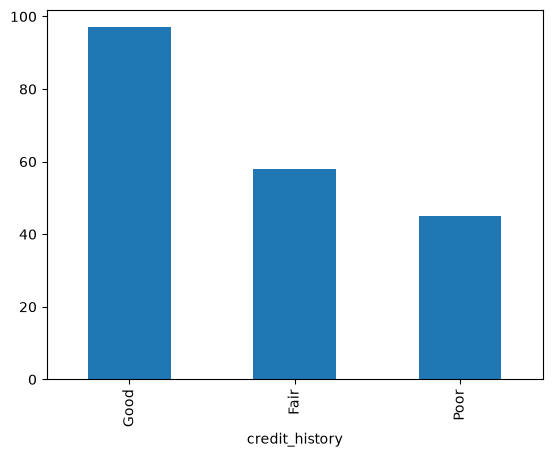

In [54]:
df['credit_history'].value_counts().plot(kind='bar')

In [55]:
df['credit_history'] = df['credit_history'].map({'Good': 2, 'Poor': 0, 'Fair':1})

In [56]:
# df['credit_history'].value_counts()
df.head()

,age,income,credit_history,loan_amount,credit_risk
0,53,87,1,22,0
1,39,51,2,9,0
2,32,108,2,29,0
3,45,76,2,6,0
4,43,71,2,14,0


In [57]:
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_classifier = DecisionTreeClassifier(criterion='gini', max_depth=6, random_state=42)
dt_classifier.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [58]:
y_pred = dt_classifier.predict(X_test)
accuracy = dt_classifier.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.85


In [59]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[26,  0],
       [ 6,  8]])

<Axes: >

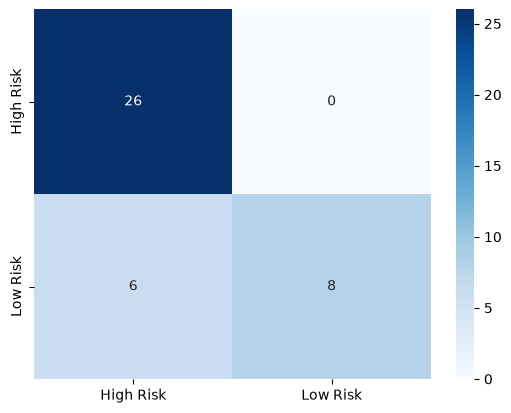

In [60]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['High Risk', 'Low Risk'], yticklabels=['High Risk', 'Low Risk'])

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90        26
           1       1.00      0.57      0.73        14

    accuracy                           0.85        40
   macro avg       0.91      0.79      0.81        40
weighted avg       0.88      0.85      0.84        40

